In [214]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp

# --- Spar Buoy Properties ---
# We'll define a coordinate system 'x' starting from the spar base (x=0) to the top (x=130m).
# This corresponds to a vertical position 'z' from z=-120m to z=+10m relative to Still Water Level (SWL).
# x = z + 120

# 1. Geometric Properties
L = 130.0       # Total length of the spar [m]
D_upper = 6.5   # Platform Diameter Above Taper [m]
D_lower = 9.4   # Platform Diameter Below Taper [m]
x_taper_bottom = 108.0 # Position of the bottom of the taper (z=-12m) [m]
x_taper_top = 116.0    # Position of the top of the taper (z=-4m) [m]
t_wall = 0.0418 # Equivalent Uniform Wall Thickness [m]

def get_diameter(x):
    """
    Returns the outer diameter of the spar at a given position x (or array of positions)
    along its length, using linear interpolation for the tapered section.
    """
    xp = [0, x_taper_bottom, x_taper_top, L]
    fp = [D_lower, D_lower, D_upper, D_upper]
    return np.interp(x, xp, fp)

def get_inner_diameter(x):
    """Returns the inner diameter based on the wall thickness."""
    return get_diameter(x) - 2 * t_wall

def get_area(x):
    """Returns the cross-sectional area A(x) of the hollow steel shell."""
    D_out = get_diameter(x)
    D_in = get_inner_diameter(x)
    return (np.pi / 4) * (D_out**2 - D_in**2)

def get_second_moment_of_area(x):
    """Returns the area moment of inertia I(x) for the hollow tube."""
    D_out = get_diameter(x)
    D_in = get_inner_diameter(x)
    return (np.pi / 64) * (D_out**4 - D_in**4)

# 2. Material and Mass Properties
E = 210e9           # Young's Modulus for steel [Pa]
rho_steel = 8500.0  # Steel Density including paint/welds [kg/m^3]
total_mass = 7466330.0 # Platform Mass, Including Ballast [kg]

# Calculate steel shell mass and the required ballast mass
# We integrate rho_steel * A(x) over the entire length of the spar
steel_mass = scp.quad(lambda x: rho_steel * get_area(x), 0, L)[0]
ballast_mass = total_mass - steel_mass

print(f"Mass of steel shell: {steel_mass:,.2f} kg")
print(f"Required ballast mass to place at bottom: {ballast_mass:,.2f} kg")

# 3. Boundary Conditions & Loads (Placeholders)
u0, u0_dt2, du0, du0_dt2 = 0, 0, 0, 0
def q(x, t):
    return 0.0


Mass of steel shell: 1,299,674.49 kg
Required ballast mass to place at bottom: 6,166,655.51 kg


In [215]:
ne = 130        # Increased number of elements (1 element per meter)
nn = ne + 1
ndofs = 2*nn
xn = np.linspace(0, L, nn)

In [216]:
elem_dofs = []
for ie in np.arange(0, ne):
    elem_dofs.append(np.arange(2*ie, 2*ie + 4))
for idof in np.arange(0, ndofs):
    dof_node.append(int(np.floor(idof/2)))

In [217]:
N_k = []
dN_k = []
ddN_k = []
h = L/ne
matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [1, h,  h**2, h**3], [0, 1, 2*h, 3*h**2]])

def base(x):
    if isinstance(x, float):
        return np.array([[1], [x], [x**2], [x**3]])
    else:
        return np.array([[np.ones(len(x))], [x], [x**2], [x**3]])
def dbase(x):
    if isinstance(x, float):
        return np.array([[0], [1], [2*x], [3*x**2]])
    else:
        return np.array([[np.zeros(len(x))], [np.ones(len(x))], [2*x], [3*x**2]])
def ddbase(x):
    if isinstance(x, float):
        return np.array([[0], [0], [2], [6*x]])
    else:
        return np.array([[np.zeros(len(x))], [np.zeros(len(x))], [2*np.ones(len(x))], [6*x]])
def make_N(coeff): 
    return lambda x: np.dot(np.transpose(base(x)), coeff)
def make_dN(coeff):
    return lambda x: np.dot(np.transpose(dbase(x)), coeff)
def make_ddN(coeff):
    return lambda x: np.dot(np.transpose(ddbase(x)), coeff)

dof_vec = np.arange(0,4)
for idof in dof_vec:
    rhs = np.zeros(len(dof_vec))
    rhs[idof] = 1
    coeff = np.linalg.solve(matrix, rhs)
    N_k.append(make_N(coeff))
    dN_k.append(make_dN(coeff))
    ddN_k.append(make_ddN(coeff))

In [218]:
import scipy.integrate as scp

M_list = []
K_list = []

# Loop over each element to compute its unique matrices
for ie in range(ne):
    x_start = xn[ie]
    M_k = np.zeros((4, 4))
    K_k = np.zeros((4, 4))
    
    for idof in range(4):
        for jdof in range(4):
            def eqn_M(local_x):
                global_x = x_start + local_x
                return rho_steel * get_area(global_x) * N_k[idof](local_x) * N_k[jdof](local_x)

            def eqn_K(local_x):
                global_x = x_start + local_x
                return E * get_second_moment_of_area(global_x) * ddN_k[idof](local_x) * ddN_k[jdof](local_x)

            M_k[idof, jdof] = scp.quad(eqn_M, 0, h)[0]
            K_k[idof, jdof] = scp.quad(eqn_K, 0, h)[0]
    
    M_list.append(M_k)
    K_list.append(K_k)

print(f"Successfully calculated {len(K_list)} unique element stiffness matrices.")


Successfully calculated 130 unique element stiffness matrices.


--- Mass & CG Check ---
Target CG:      z = -89.9155 m
Calculated CG:  z = -89.9177 m
Total Mass:     7,466,330 kg
Ballast Fill:   From z = -120.00 m up to z = -73.49 m
-----------------------
Heave stiffness (C33):  333,664 N/m
Pitch stiffness (C55):  4,110,000,000 N·m/rad


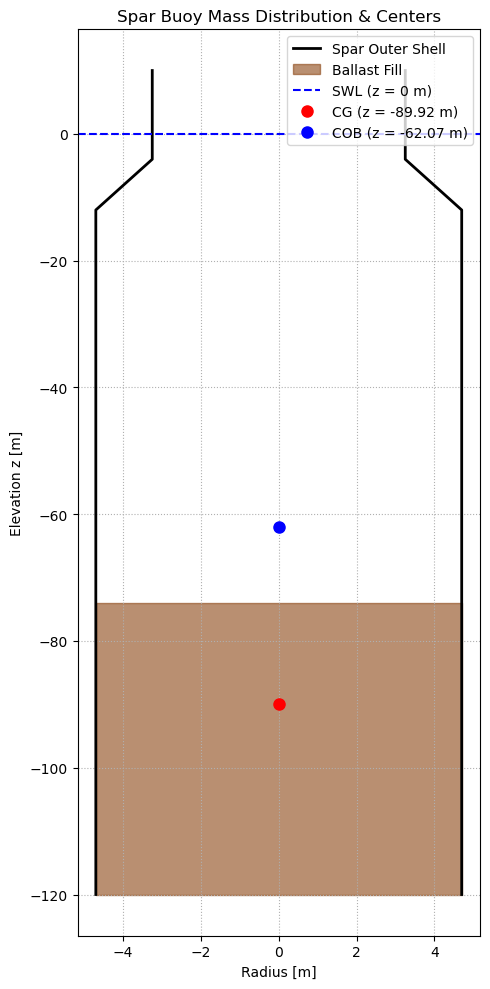

In [219]:
# Initialize global matrices
M_global = np.zeros((ndofs, ndofs))
K_global = np.zeros((ndofs, ndofs))

# 1. Assemble the baseline structural matrices
for ie in range(ne):
    dofs = elem_dofs[ie]
    M_global[np.ix_(dofs, dofs)] += M_list[ie]
    K_global[np.ix_(dofs, dofs)] += K_list[ie]

# --- 2. The CG Balancing Method for Ballast ---
target_z_cg = -89.9155
target_x_cg = 120.0 + target_z_cg # 30.0845 m from the base

# Calculate baseline steel mass properties from the consistent mass matrix
m_nodes = np.array([np.sum(M_global[2*i, ::2]) for i in range(nn)])
steel_moment = np.sum(m_nodes * xn)

# Calculate required ballast moment to hit target CG perfectly
req_ballast_moment = (total_mass * target_x_cg) - steel_moment

# Assuming ballast fills from x=0 uniformly up to H_fill.
# CG of this uniform fill is at H_fill / 2.
# req_ballast_moment = ballast_mass * (H_fill / 2)
H_fill = 2.0 * (req_ballast_moment / ballast_mass)
density_ballast = ballast_mass / H_fill

# Distribute ballast mass to the nodes covered by H_fill
for i in range(nn):
    x = xn[i]
    # Calculate how much of this node's tributary length is within the fill height
    x_start = max(0.0, x - h/2.0)
    x_end = min(H_fill, x + h/2.0)
    
    if x_start < x_end:
        node_ballast = density_ballast * (x_end - x_start)
        M_global[2*i, 2*i] += node_ballast # Add to translational DOF
        m_nodes[i] += node_ballast         # Update our mass tracker array

# --- Check the Math (The requested for loop) ---
cg_numerator = 0.0
cg_denominator = 0.0
for i in range(nn):
    z_i = xn[i] - 120.0 # Convert to elevation relative to SWL
    cg_numerator += m_nodes[i] * z_i  # mass_i * z_i
    cg_denominator += m_nodes[i]      # total mass

calculated_cg_z = cg_numerator / cg_denominator

print("--- Mass & CG Check ---")
print(f"Target CG:      z = {target_z_cg:.4f} m")
print(f"Calculated CG:  z = {calculated_cg_z:.4f} m")
print(f"Total Mass:     {cg_denominator:,.0f} kg")
print(f"Ballast Fill:   From z = -120.00 m up to z = {H_fill - 120.0:.2f} m")
print("-----------------------")

# --- 3. Added Mass (Hydrodynamics) ---
rho_water = 1025.0 # Density of seawater [kg/m^3]
C_a = 1.0          # Added mass coefficient

for i_node in range(121): # Nodes 0 to 120 (z = -120m to 0m)
    x_node = xn[i_node]
    outer_diameter = get_diameter(x_node)
    outer_area = (np.pi / 4) * outer_diameter**2
    
    if i_node == 0 or i_node == 120:
        L_tributary = h / 2.0
    else:
        L_tributary = h
        
    displaced_mass = rho_water * outer_area * L_tributary
    added_mass = C_a * displaced_mass
    M_global[2*i_node, 2*i_node] += added_mass

# --- 4. Hydrostatic Restoring Stiffness ---
g = 9.81  # Gravitational acceleration [m/s^2]
node_swL = 120

# Calculate heave stiffness C33 from waterplane area
D_at_swL = get_diameter(xn[node_swL])
A_waterplane = (np.pi / 4) * D_at_swL**2
C33_heave_stiffness = rho_water * g * A_waterplane

# Pitch stiffness from NREL
C55_pitch_stiffness = 4.11e9

# Apply both to K_global at the SWL node
dof_heave_swL = 2 * node_swL  # Translational DOF
dof_pitch_swL = 2 * node_swL + 1  # Rotational DOF

K_global[dof_heave_swL, dof_heave_swL] += C33_heave_stiffness
K_global[dof_pitch_swL, dof_pitch_swL] += C55_pitch_stiffness

print(f"Heave stiffness (C33):  {C33_heave_stiffness:,.0f} N/m")
print(f"Pitch stiffness (C55):  {C55_pitch_stiffness:,.0f} N·m/rad")

# --- 5. Generate the Plot ---
z_coords = xn - 120.0
outer_diameters = get_diameter(xn)

# Calculate COB (Center of Buoyancy)
submerged_mask = z_coords <= 0
xn_sub = xn[submerged_mask]
A_sub = (np.pi / 4) * get_diameter(xn_sub)**2
V_sub = np.trapz(A_sub, xn_sub)
Moment_sub = np.trapz(xn_sub * A_sub, xn_sub)
cob_x = Moment_sub / V_sub
cob_z = cob_x - 120.0

fig, ax = plt.subplots(figsize=(5, 10))

# Plot Spar Shell
ax.plot(outer_diameters/2, z_coords, 'k', linewidth=2, label='Spar Outer Shell')
ax.plot(-outer_diameters/2, z_coords, 'k', linewidth=2)

# Plot Fill Area
ballast_mask = z_coords <= (H_fill - 120.0)
ax.fill_betweenx(z_coords[ballast_mask], -outer_diameters[ballast_mask]/2, outer_diameters[ballast_mask]/2, 
                 color='saddlebrown', alpha=0.6, label='Ballast Fill')

# Draw SWL
ax.axhline(0, color='blue', linestyle='--', linewidth=1.5, label='SWL (z = 0 m)')

# Markers
ax.plot(0, calculated_cg_z, 'ro', markersize=8, label=f'CG (z = {calculated_cg_z:.2f} m)')
ax.plot(0, cob_z, 'bo', markersize=8, label=f'COB (z = {cob_z:.2f} m)')

ax.set_xlabel('Radius [m]')
ax.set_ylabel('Elevation z [m]')
ax.set_title('Spar Buoy Mass Distribution & Centers')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

In [220]:
#%% GET THE MOORING DATA
# These tables are generated from the mooring line script.

# The mooring offsets that converged to the specified horizontal forces.
mooring_offset = np.array([0, 3.49,  7.28, 10.15, 12.31, 13.9 , 15.12, 16.23, 17.15, 17.98,
          18.74, 19.5 , 20.22, 20.89, 21.54, 22.19, 22.85, 23.5 , 24.13,
          24.75, 25.38, 25.97, 26.59, 27.22, 27.84, 28.44, 29.05, 29.67,
          30.25, 30.86, 31.48])

mooring_hforce = np.linspace(0, 3e6, 31)

# Fx, Fz components on left, right hand sides
mooring_table = np.array([[  -301446.60422046,   -349797.48464005,   -410631.37652927,
           -470825.79506971,   -556149.09198733,   -645566.18232553,
           -734675.91644729,   -833331.58786685,   -927824.59341565,
          -1022160.27303207,  -1115123.41246619,  -1213381.04277708,
          -1310492.89336252,  -1403732.66190896,  -1496351.12914373,
          -1590714.92691488,  -1687995.05852086,  -1784986.08038156,
          -1879919.1421873 ,  -1974086.30735597,  -2070403.15388061,
          -2161091.876147  ,  -2256823.13777638,  -2354484.90199056,
          -2450921.91636203,  -2544512.82574782,  -2639895.02460998,
          -2737049.1603971 ,  -2828101.84453703,  -2924017.01692269,
          -3021646.51349001],

       [ -2687887.6881004 ,  -3004799.94010243,  -3527369.94912642,
          -4198179.18029163,  -4958975.40782282,  -5756274.47459234,
          -6550832.95985101,  -7430509.03135846,  -8273068.15350561,
          -9114224.45860071,  -9943142.33139713, -10819269.21780724,
         -11685179.61090077, -12516564.08300457, -13342408.64149557,
         -14183815.66575911, -15051226.55836705, -15916059.5664874 ,
         -16762542.50724299, -17602196.23143975, -18461017.86786101,
         -19269655.60541241, -20123255.79827353, -20994069.56745934,
         -21853962.69605019, -22688478.16092576, -23538965.8904145 ,
         -24405253.32498528, -25217136.37572034, -26072376.4326589 ,
         -26942902.48319222],

       [   315260.63321602,    240340.22133834,    210548.57039374,
            185368.97616293,    164951.50323532,    158680.01225456,
            146983.8736424 ,    145386.5577522 ,    140036.26571395,
            131021.36772318,    128771.53864652,    128483.45088051,
            126479.43383188,    122553.74594811,    115161.93944116,
            113569.01718246,    113591.64593374,    112059.31853292,
            108700.09507975,    107329.48739852,    106005.16000889,
             99718.59121803,     98526.42697658,     95561.12345424,
             94435.99487217,     94568.53430948,     93484.57134842,
             92433.88998479,     86963.23910028,     86009.09242459,
             83442.96785209],

       [ -2693198.75156988,  -2396810.98317966,  -2140844.1623609 ,
          -1975535.70580681,  -1865967.23116873,  -1789537.39082197,
          -1736371.80912458,  -1688767.71969355,  -1651371.05794757,
          -1619547.19064498,  -1591737.18969741,  -1562691.06139977,
          -1538317.03106889,  -1514335.98708205,  -1492701.74259443,
          -1472054.66211879,  -1449827.49668397,  -1430269.62883749,
          -1410625.81525124,  -1392839.12816227,  -1375653.03092578,
          -1358563.91305217,  -1342321.89341394,  -1324478.49555432,
          -1308884.19781243,  -1292147.63910165,  -1277336.79116759,
          -1262980.69002487,  -1248574.86145418,  -1234875.69884554,
          -1219926.43058617]])

mooring_table[1] -= mooring_table[1][0]
mooring_table[3] -= mooring_table[3][0]

def Fmoor(x):
    fxl = np.interp(x, mooring_offset, mooring_table[0])
    fzl = np.interp(x, mooring_offset, mooring_table[1])
    fxr = np.interp(x, mooring_offset, mooring_table[2])
    fzr = np.interp(x, mooring_offset, mooring_table[3])
    
    return fxl, fzl, fxr, fzr

# The fairleads are attached 70.0 m below SWL (z = -70m), corresponding to x = 50m.
mooring_node = 50
mooring_dof = 2 * mooring_node
print(f"Mooring lines attached at node {mooring_node} (DOF {mooring_dof})")


Mooring lines attached at node 50 (DOF 100)


Assembling analytical Jacobian to speed up BDF solver...
Solving time-domain dynamics...
Solution converged: True


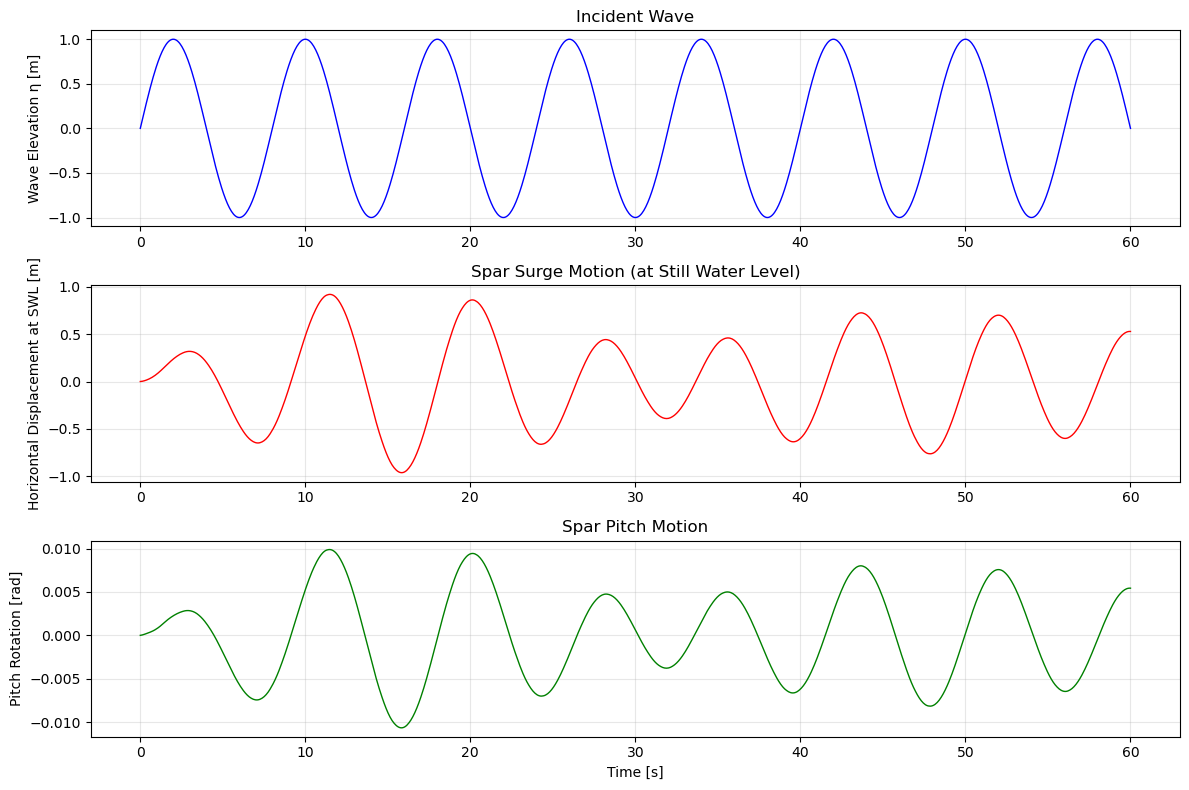

Max surge displacement: 0.964 m
Max pitch rotation: 0.010663 rad (0.611°)


In [221]:
# --- TIME DOMAIN RESPONSE TO WAVES ---
# Use the M_global and K_global matrices built from spar buoy properties

# Wave parameters (general sinusoidal for now)
wave_amplitude = 1.0  # Wave height [m]
wave_period = 8.0     # Wave period [s]
wave_freq = 2 * np.pi / wave_period  # Angular frequency [rad/s]

# Simulation time
t_final = 60.0  # Simulate 60 seconds
n_steps = 1000
t_eval = np.linspace(0, t_final, n_steps)

# Define wave surface elevation
def wave_eta(t):
    return wave_amplitude * np.sin(wave_freq * t)

# --- PRE-CALCULATE WAVE CONSTANTS ONCE OUTSIDE THE LOOP ---
k_wave = wave_freq**2 / 9.81
wave_areas = np.zeros(121)
depth_decays = np.zeros(121)
L_tribs = np.zeros(121)

for i_node in range(121):
    x_node = xn[i_node]
    z_node = x_node - 120.0
    
    wave_areas[i_node] = (np.pi / 4) * get_diameter(x_node)**2
    depth_decays[i_node] = np.exp(k_wave * z_node)
    L_tribs[i_node] = (h / 2.0) if (i_node == 0 or i_node == 120) else h

# --- THE NEW, LIGHTNING-FAST WAVE FUNCTION ---
def compute_wave_loading(t):
    F_wave = np.zeros(ndofs)
    
    # Calculate the time-dependent part once
    surface_accel = wave_amplitude * wave_freq**2 * np.cos(wave_freq * t)
    
    # Vectorized calculation (No 'for' loops!)
    F_horizontal = rho_water * wave_areas * (surface_accel * depth_decays) * L_tribs
    
    # Apply to the horizontal DOFs (every other index up to 240)
    F_wave[0:242:2] += F_horizontal 
    
    return F_wave

# Define mooring restoring forces
def compute_mooring_forces(u_mooring):
    F_mooring = np.zeros(ndofs)
    
    # The table only has positive offsets. We take the absolute value of the displacement.
    offset = np.abs(u_mooring)
    
    # Get the forces from the lookup table
    fxl, fzl, fxr, fzr = Fmoor(offset)
    
    # Net horizontal restoring force is the sum of the left (pulling back) and right (slackening) lines
    # fxl is highly negative, fxr is slightly positive. 
    net_Fx = fxl + fxr 
    
    # If the turbine swayed backward (negative u), the direction of the restoring force flips
    if u_mooring < 0:
        net_Fx = -net_Fx
        
    F_mooring[2*mooring_node] = net_Fx
    return F_mooring

# Initial conditions
u0_global = np.zeros(ndofs)  # Initial displacement
v0_global = np.zeros(ndofs)  # Initial velocity

# Convert to first-order state-space: [u, v] where du/dt = v, dv/dt = M^-1(F - Ku)
# Create a global damping matrix (Rayleigh Damping)
# These coefficients are typical approximations for offshore steel structures (approx 1-5% damping)
alpha_damp = 0.05 
beta_damp = 0.02
C_global = alpha_damp * M_global + beta_damp * K_global

y0 = np.concatenate([u0_global, v0_global])


M_inv = np.linalg.inv(M_global)             # Precompute M^-1 for efficiency in the ODE function
# ODE function for solve_ivp
def odefun(t, y):
    u = y[:ndofs]
    v = y[ndofs:]

    F_wave = compute_wave_loading(t)
    F_mooring = compute_mooring_forces(u[2*mooring_node])
    F_total = F_wave + F_mooring

    # Acceleration: u_dd = M^-1(F_total - C*v - K*u)
    damping_force = np.dot(C_global, v)
    stiffness_force = np.dot(K_global, u)
    
    u_dd = np.dot(M_inv, (F_total - damping_force - stiffness_force))

    return np.concatenate([v, u_dd])

# --- PRE-COMPUTE THE EXACT JACOBIAN MATRIX ---
print("Assembling analytical Jacobian to speed up BDF solver...")
I_mat = np.eye(ndofs)
Z_mat = np.zeros((ndofs, ndofs))

# The top half of the Jacobian (derivative of velocity is acceleration)
J_top = np.hstack((Z_mat, I_mat))

# The bottom half of the Jacobian (derivative of acceleration w.r.t u and v)
# We ignore the microscopic non-linear mooring stiffness here; the massive structural K is enough.
J_bot = np.hstack((-np.dot(M_inv, K_global), -np.dot(M_inv, C_global)))

# Combine them into a single 524x524 matrix
Jacobian_matrix = np.vstack((J_top, J_bot))

# --- SOLVE ODE ---
print("Solving time-domain dynamics...")
sol = scp.solve_ivp(
    odefun, 
    [t_eval[0], t_eval[-1]], 
    y0, 
    t_eval=t_eval, 
    method='BDF', 
    jac=Jacobian_matrix,
    rtol=1e-2,         # <--- NEW: Allow 1% relative error
    atol=1e-3          # <--- NEW: Allow 1 millimeter absolute error
)
print(f"Solution converged: {sol.status == 0}")

# Extract results
u_sol = sol.y[:ndofs, :]
v_sol = sol.y[ndofs:, :]

# Plot wave surface elevation and spar response
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Wave elevation
axes[0].plot(sol.t, wave_amplitude * np.sin(wave_freq * sol.t), 'b-', linewidth=1)
axes[0].set_ylabel('Wave Elevation η [m]')
axes[0].set_title('Incident Wave')
axes[0].grid(True, alpha=0.3)

# Spar horizontal motion at SWL (node 120, translational DOF)
dof_swL_horiz = 2 * node_swL
axes[1].plot(sol.t, u_sol[dof_swL_horiz, :], 'r-', linewidth=1)
axes[1].set_ylabel('Horizontal Displacement at SWL [m]')
axes[1].set_title('Spar Surge Motion (at Still Water Level)')
axes[1].grid(True, alpha=0.3)

# Spar pitch (rotation at node 120)
dof_swL_pitch = 2 * node_swL + 1
axes[2].plot(sol.t, u_sol[dof_swL_pitch, :], 'g-', linewidth=1)
axes[2].set_ylabel('Pitch Rotation [rad]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Spar Pitch Motion')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max surge displacement: {np.max(np.abs(u_sol[dof_swL_horiz, :])):.3f} m")
print(f"Max pitch rotation: {np.max(np.abs(u_sol[dof_swL_pitch, :])):.6f} rad ({np.degrees(np.max(np.abs(u_sol[dof_swL_pitch, :]))):.3f}°)")

In [222]:
# This cell contained old 1D cantilever beam code - no longer needed.
# The time-domain solver in the previous cell (425973b5) handles the spar buoy dynamics.
# The solver uses:
# - M_global: mass matrix with structural mass, ballast, and added mass
# - K_global: stiffness matrix with beam stiffness, hydrostatic restoring, and pitch restoring
# - Wave loading: distributed horizontal forces on submerged nodes
# - Mooring restoring: linear stiffness at the fairlead node
print("Time-domain spar buoy solver ready. Run the previous cell to simulate wave response.")

Time-domain spar buoy solver ready. Run the previous cell to simulate wave response.
